# Comprehensive Report on Climate Change

In [884]:
# import the packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import table

In [885]:
# import the dataset
climate = pd.read_csv('climate_change_dataset-2.csv')
climate.head()

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4


In [886]:
# check the datatype
climate.dtypes

Year                             int64
Country                         object
Avg Temperature (°C)           float64
CO2 Emissions (Tons/Capita)    float64
Sea Level Rise (mm)            float64
Rainfall (mm)                    int64
Population                       int64
Renewable Energy (%)           float64
Extreme Weather Events           int64
Forest Area (%)                float64
dtype: object

In [887]:
# check for missing values in the data
missing_values = climate.isnull().sum()
print(missing_values)

Year                           0
Country                        0
Avg Temperature (°C)           0
CO2 Emissions (Tons/Capita)    0
Sea Level Rise (mm)            0
Rainfall (mm)                  0
Population                     0
Renewable Energy (%)           0
Extreme Weather Events         0
Forest Area (%)                0
dtype: int64


In [888]:
climate.describe()

,Year,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,2011.432000,19.883100,10.425800,3.009600,1738.761000,7.053830e+08,27.300500,7.291000,40.572000
std,7.147199,8.542897,5.614665,1.146081,708.976616,4.093910e+08,12.970808,4.422655,17.398998
min,2000.000000,5.000000,0.500000,1.000000,501.000000,3.660891e+06,5.100000,0.000000,10.100000
25%,2005.000000,12.175000,5.575000,2.000000,1098.750000,3.436242e+08,16.100000,3.000000,25.600000
50%,2012.000000,20.100000,10.700000,3.000000,1726.000000,7.131166e+08,27.150000,8.000000,41.150000
75%,2018.000000,27.225000,15.400000,4.000000,2362.500000,1.073868e+09,38.925000,11.000000,55.800000
max,2023.000000,34.900000,20.000000,5.000000,2999.000000,1.397016e+09,50.000000,14.000000,70.000000


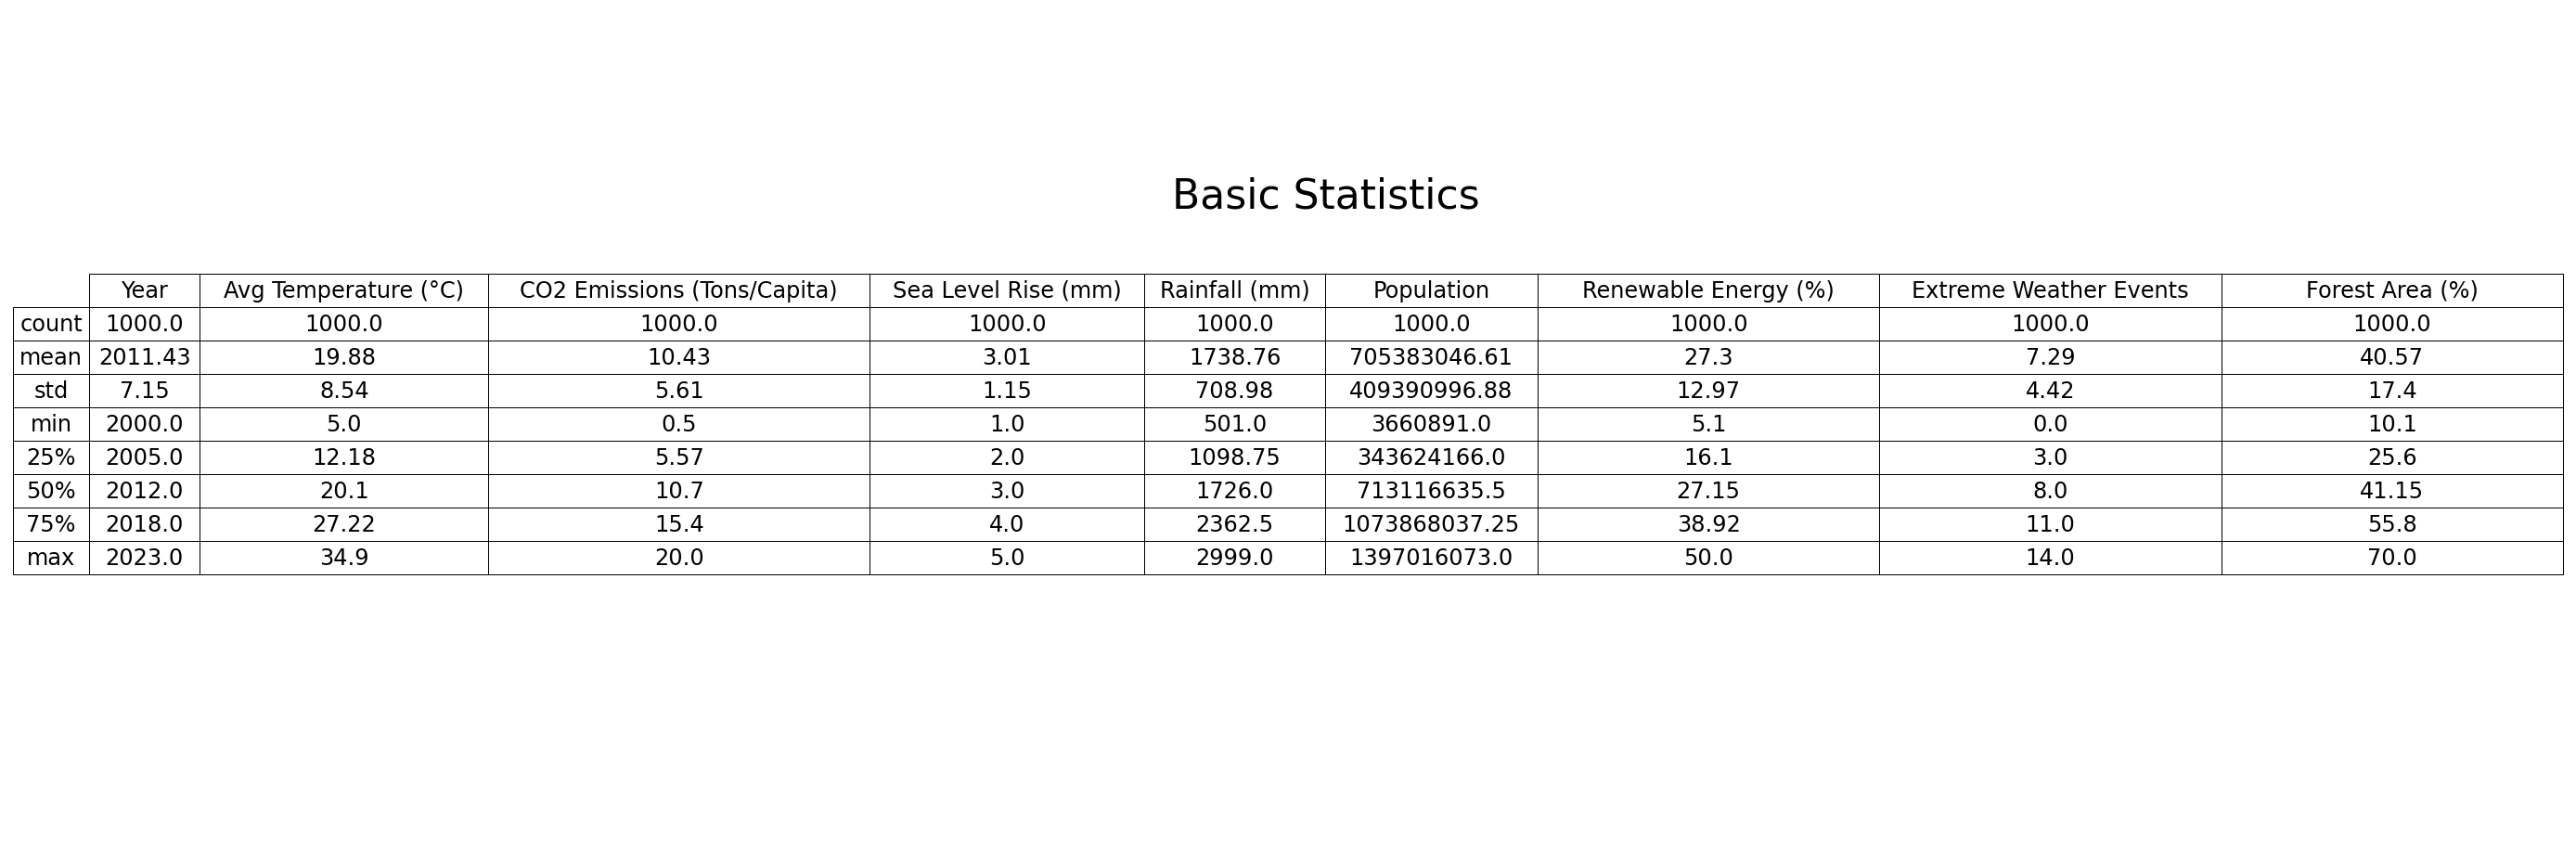

In [889]:
# basic statistics
statistics = climate.describe()

# round the statistics to 2 decimal places
statistics = statistics.round(2)

# create a figure of the basic statistics
fig, ax = plt.subplots(figsize = (22,8), dpi = 144)

# hide the axes 
ax.axis('off')

# create the table
col_widths = [0.1] * len(statistics.columns)
stat = table(ax, statistics, loc = 'center', colWidths = col_widths)

# to align the table values to center
for key, cell in stat.get_celld().items():
    cell.set_text_props(ha = 'center', va = 'center', fontsize = 18)

# formatting
stat.set_fontsize(16)
stat.auto_set_column_width([0,1,2,3,4,5])
stat.scale(1.5,1.5)

# add title
plt.title('Basic Statistics', color = 'black', fontsize = 22, y = 0.75)

# save basic statistics table as an image
plt.savefig('describe.png', bbox_inches = 'tight', dpi = 400)
plt.show()

## Graph 1: Line Plot

In [891]:
def plot_yearly_data(climate):
    """
    plots the time series data for Average Temperature (°C), CO2 Emissions (Tons/Capita), Forest Area (%)
    """

    # create a figure
    plt.figure(figsize = (10,6), dpi = 144)

    # create line plot 
    sns.lineplot(x = 'Year', y = 'Avg Temperature (°C)', data = climate, label = 'Average Temperature(°C)',
                 linestyle = 'solid', marker = 's', errorbar = None)
    sns.lineplot(x = 'Year', y = 'CO2 Emissions (Tons/Capita)', data = climate, label = 'CO2 Emisisons(Tons/Capita)', 
                 linestyle = 'solid',  marker = 's', errorbar = None)
    sns.lineplot(x = 'Year', y = 'Forest Area (%)', data = climate, label = 'Forest Area(%)', 
                 linestyle = 'solid', marker = 's', errorbar = None)
    
    # formatting
    plt.title('Climate Change Trends', color = 'black', fontsize = 16)
    plt.xlabel('Year', color = 'black', fontsize = 14)
    plt.ylabel('Value', color = 'black', fontsize = 14)
    plt.xticks(color = 'black', fontsize = 12)
    plt.yticks(color = 'black', fontsize = 12)
    plt.grid(False)

    # add legend
    plt.legend(bbox_to_anchor =(0.98,0.55), loc = 'center right')

    # save the plot
    plt.savefig('line.png', bbox_inches = 'tight', dpi = 400)
    

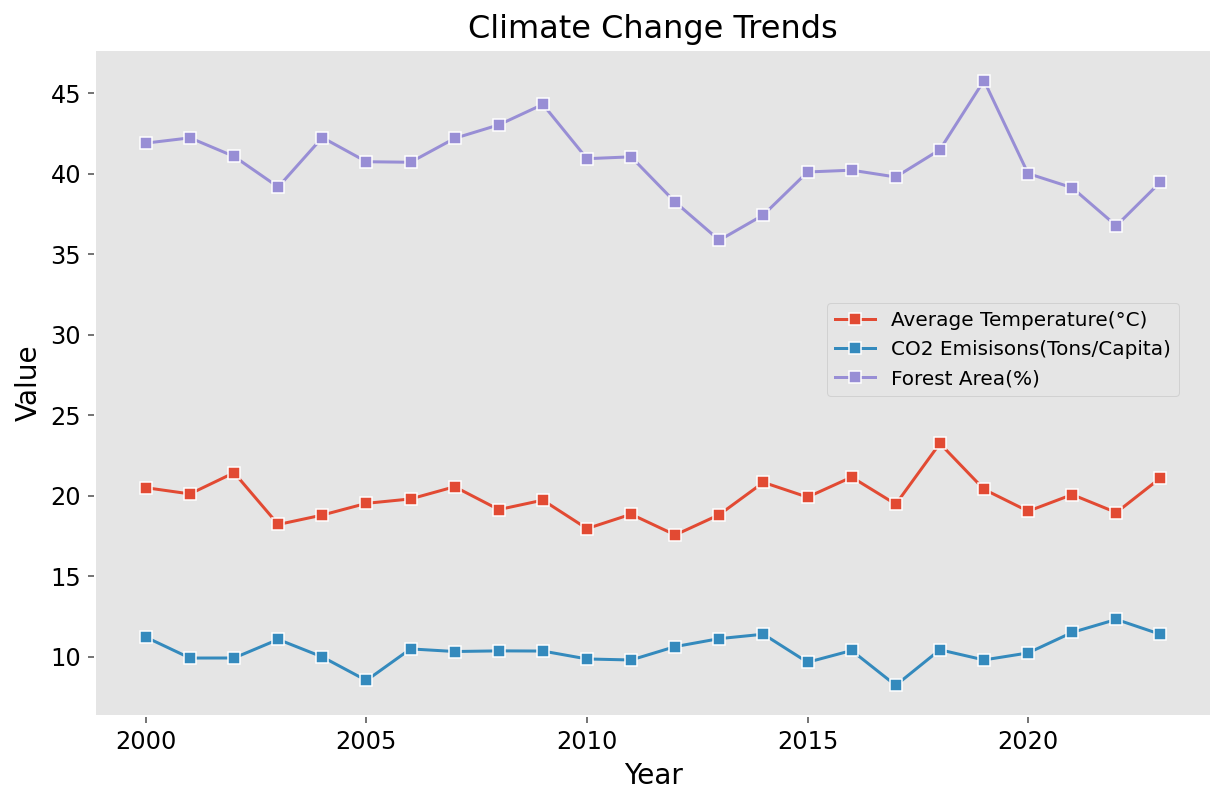

In [892]:
# display the plot
plot_yearly_data(climate)

## Graph 2 : Histogram

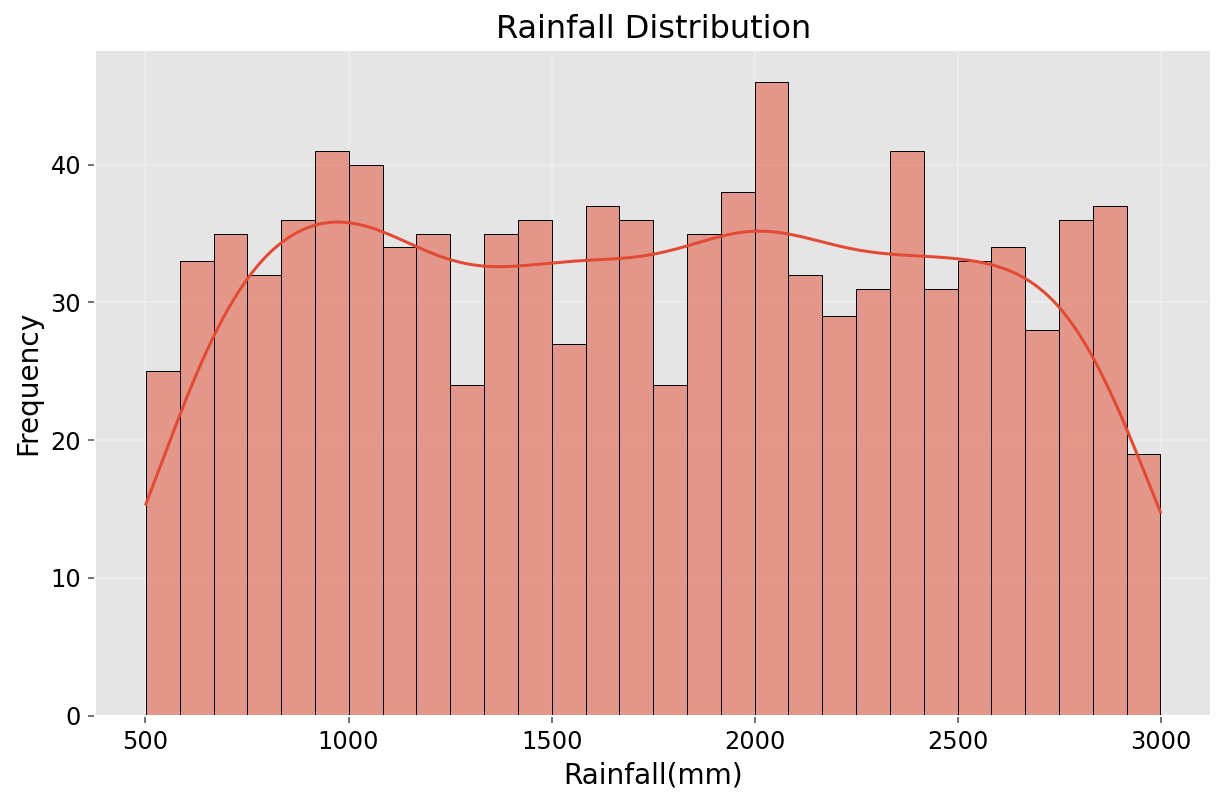

In [894]:
# plotting style
plt.style.use("ggplot")

# create a figure
plt.figure(figsize = (10,6), dpi = 144)

# histogram
sns.histplot(data = climate, x = 'Rainfall (mm)', kde = True, bins = 30, edgecolor = 'black', alpha = 0.5)
    
# add title 
plt.title('Rainfall Distribution', color = 'black', fontsize = 16)

# formatting
plt.xlabel('Rainfall(mm)', color ='black', fontsize = 14)
plt.ylabel('Frequency', color = 'black', fontsize = 14)
plt.xticks(color = 'black', fontsize = 12)
plt.yticks(color = 'black', fontsize = 12)
plt.grid(True, alpha = 0.3)

# display and save the plot
plt.savefig('hist.png', bbox_inches = 'tight', dpi = 400)

In [895]:
# skewness for Rainfall Distribution
climate_skew_kurt_check = climate [['Rainfall (mm)']].copy()
climate_skew_kurt_check.skew()

Rainfall (mm)    0.016555
dtype: float64

In [896]:
# Kurtosis for Rainfall Distribution
climate_skew_kurt_check.kurtosis()

Rainfall (mm)   -1.207742
dtype: float64

## Graph 3: Heatmap

In [898]:
# dropping irrelevant columns for heatmap
climate2 = climate.drop(columns = ['Avg Temperature (°C)', 'CO2 Emissions (Tons/Capita)', 'Rainfall (mm)', 
                                   'Renewable Energy (%)', 'Forest Area (%)', 'Year','Country'])
climate2


,Sea Level Rise (mm),Population,Extreme Weather Events
0,3.1,530911230,14
1,4.2,107364344,8
2,2.2,441101758,9
3,3.2,1069669579,7
4,2.4,124079175,4
...,...,...,...
995,1.2,1358019778,8
996,2.2,876123161,14
997,4.7,1120533308,10
998,3.1,380662109,3


In [899]:
def plot_heatmap(climate2):
    """
    plots correlation of climate change variables
    """

    # create a figure 
    plt.figure(dpi = 144)
    
    #heatmap
    sns.heatmap(climate2.corr(), annot = True, vmin = -1, vmax = 1, cmap = 'coolwarm')

    # add title
    plt.title('Correlation of Climate Change Variables', fontsize = 16)

    # formatting
    plt.xticks(color = 'black', fontsize = 12, rotation = 90)
    plt.yticks(color = 'black', fontsize = 12)

    # save the plot 
    plt.savefig('heatmap.png', bbox_inches = 'tight', dpi = 400)

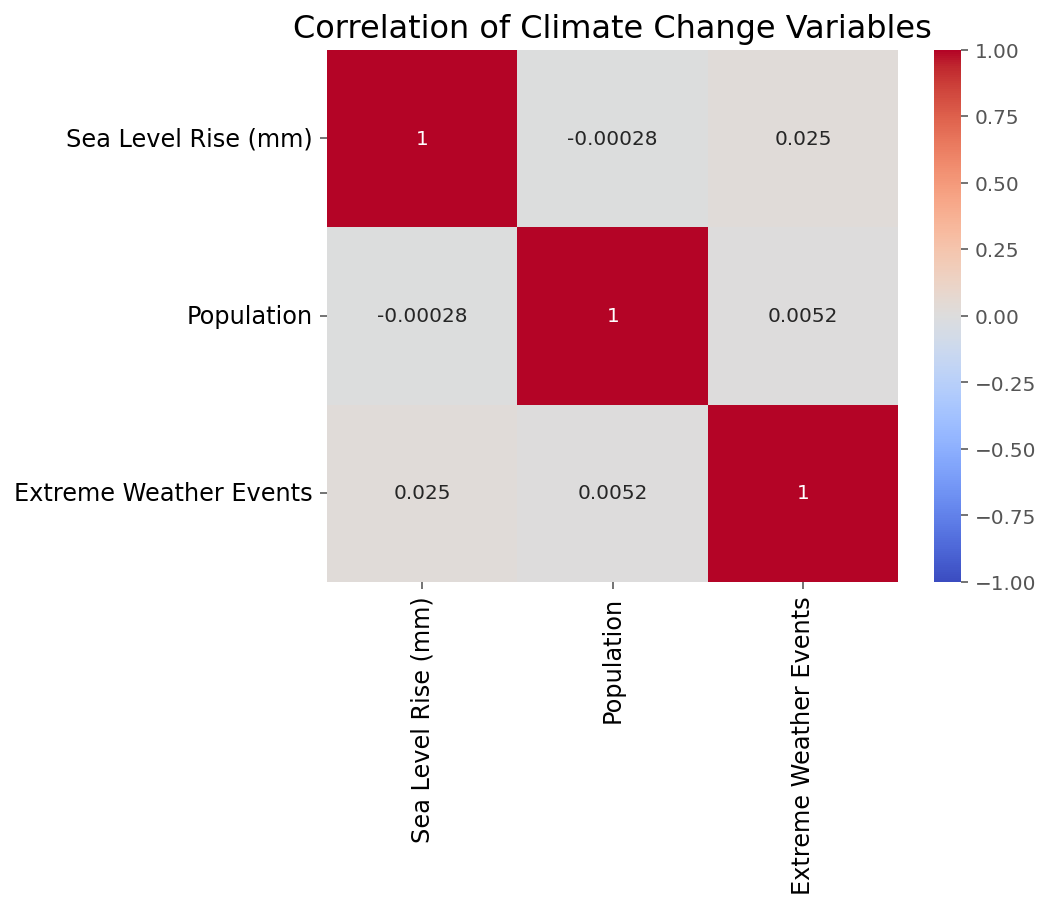

In [900]:
# display the plot
plot_heatmap(climate2)

## Graph 4: Box Plot

In [902]:
# calculate median and variance 
median_renewable_energy = climate['Renewable Energy (%)'].median()
var_renewable_energy = climate['Renewable Energy (%)'].var()

print(f"Median: {median_renewable_energy:.2f}")
print(f"Variance: {var_renewable_energy:.2f}", end = '\n\n')


def plot_box(climate):
    """
    plots the Renewable Energy variations between Countries
    """

    # create a figure 
    plt.figure(figsize = (15,8), dpi = 144)

    # box plot                
    sns.boxplot(data = climate, x = 'Renewable Energy (%)', y = 'Country', color = 'pink',
                boxprops = dict(edgecolor = 'green', linewidth = 1.5), 
                medianprops = dict(color = 'red', linewidth = 1.5), 
                whiskerprops = dict(color = 'green', linewidth = 1.5),
                capprops = dict(color = 'green', linewidth = 1.5))

    # add title
    plt.title('Renewable Energy Variations across Countries', fontsize = 22)

    # formatting
    plt.xlabel('Renewable Energy(%)', color = 'black', fontsize = 20)
    plt.ylabel('Country', color = 'black', fontsize = 20)
    plt.xticks(color = 'black', fontsize = 18)
    plt.yticks(color = 'black', fontsize = 18)           
    plt.grid(axis = 'x', linestyle = 'solid', alpha = 0.3)
    
    # save the plot
    plt.savefig('box.png', bbox_inches = 'tight', dpi = 400)

Median: 27.15
Variance: 168.24



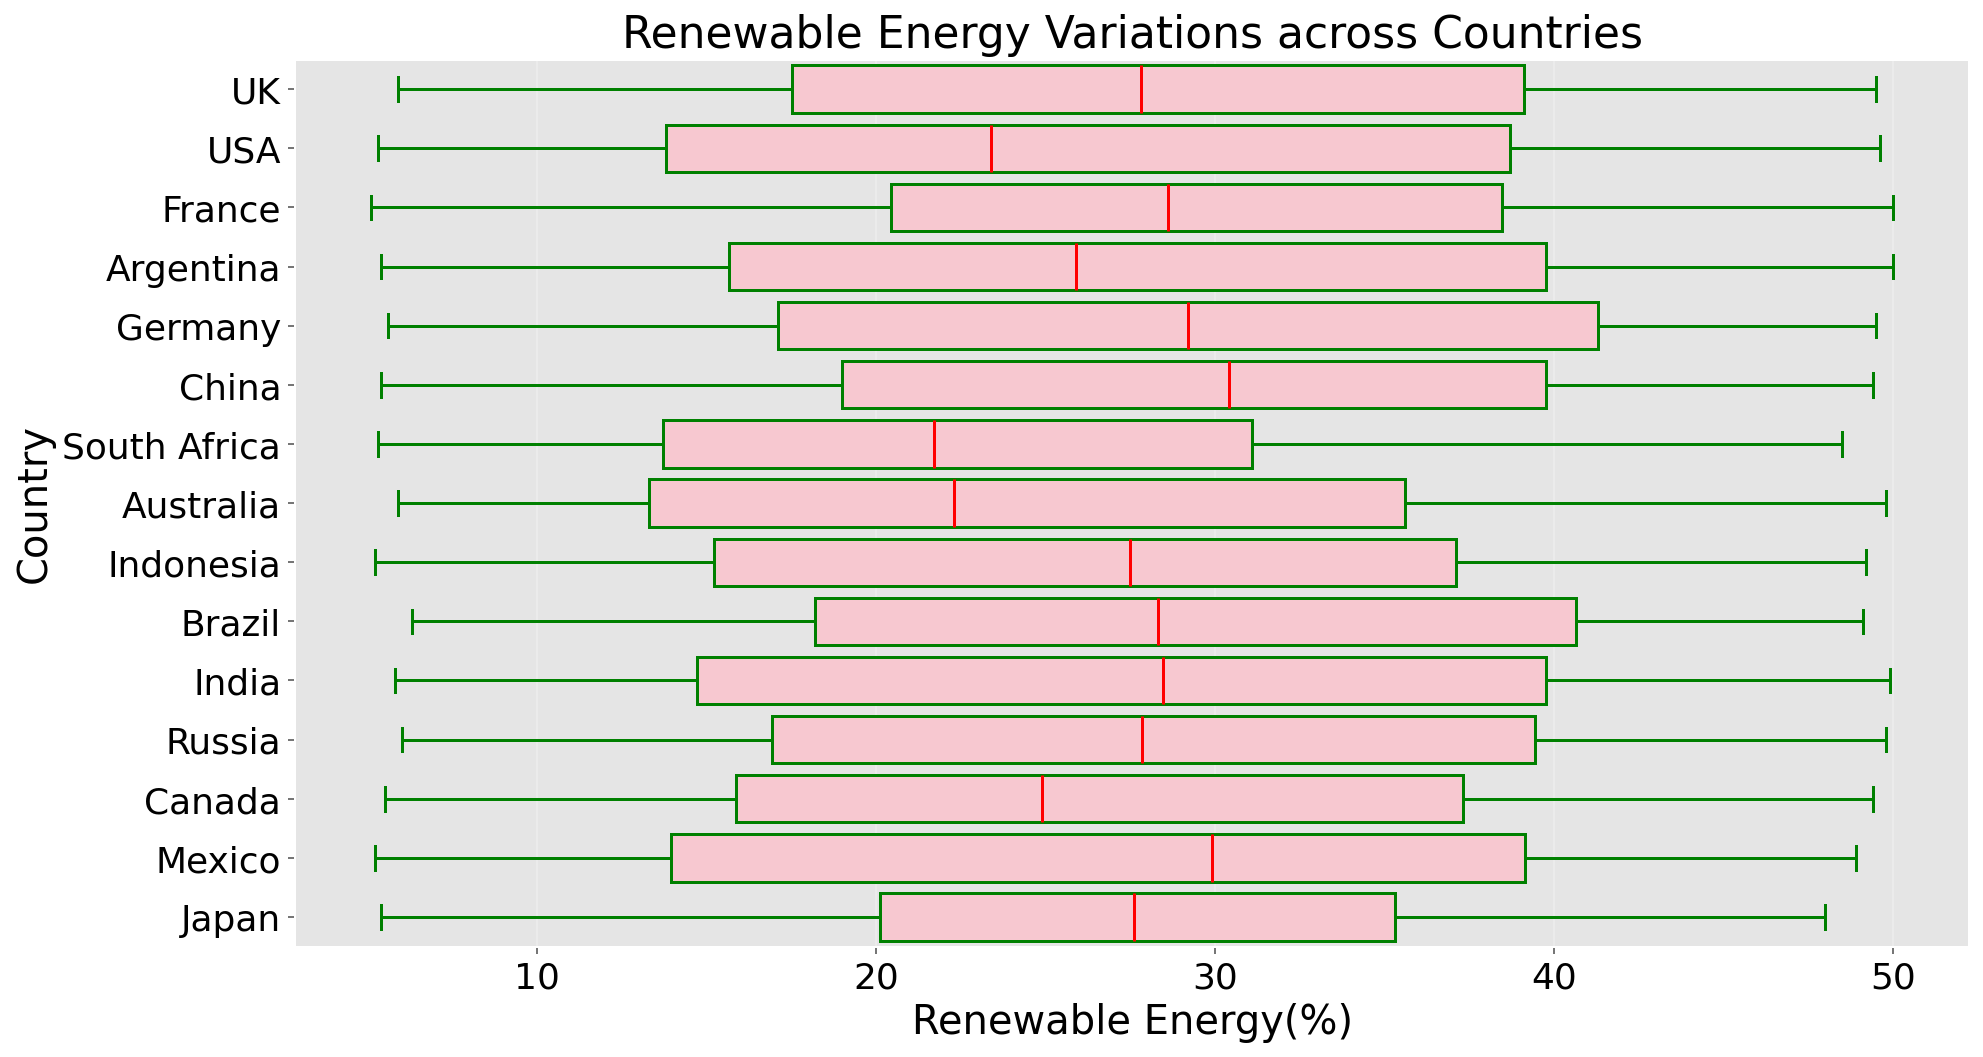

In [903]:
# display the plot
plot_box(climate)